In [1]:
!pip install pyspark -q
print("PySpark installed")

PySpark installed


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports done")

All imports done


In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

Mounted at /content/drive
Drive mounted


In [4]:
spark = (
    SparkSession.builder
    .appName("nyc-taxi-demand-pricing")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Session ready")

Spark version: 4.0.3
Session ready


In [5]:
DRIVE_PATH = "/content/drive/.shortcut-targets-by-id/1AG7n5J82rGTCKZTIhAWnWDJ0Ia16Ugcb/all_months_cleaned"

df = spark.read.parquet(DRIVE_PATH)

print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")
df.printSchema()

Total rows: 43,790,431
Total columns: 35
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- trip_duration_minutes: double

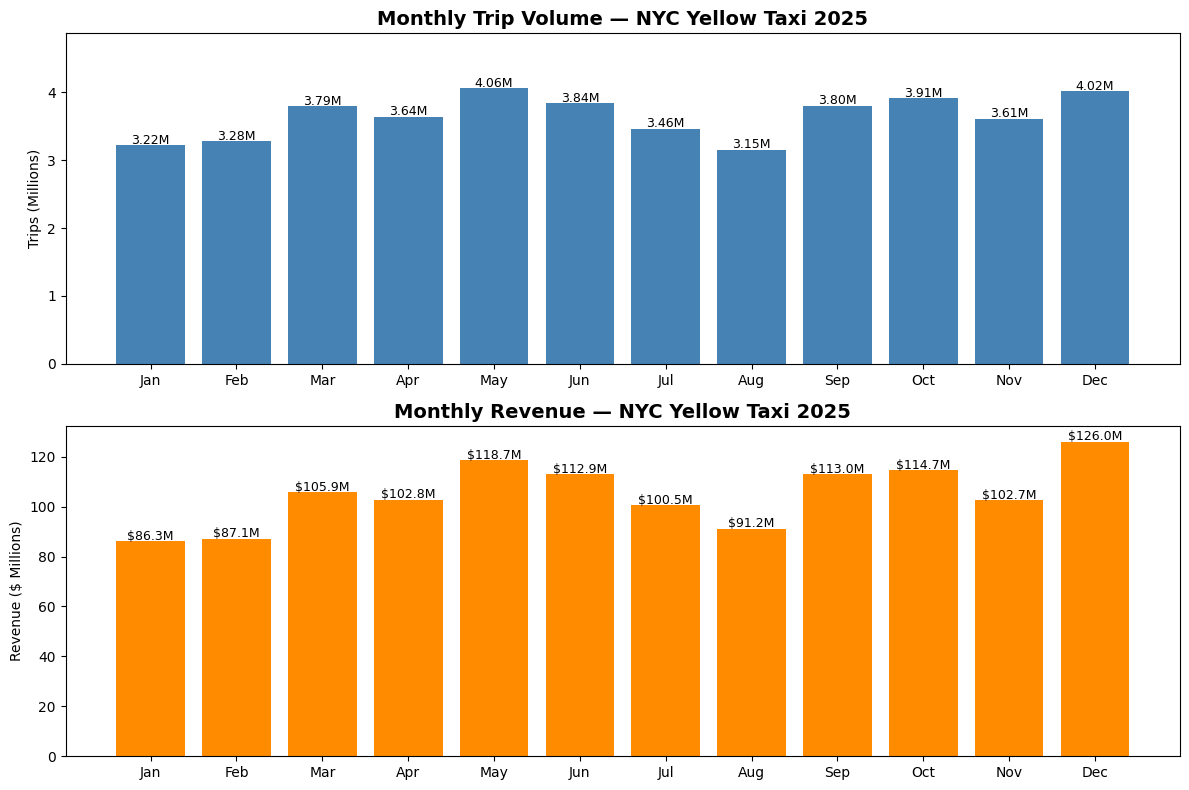

Task 1 done


In [6]:
# Monthly trip volume & revenue
monthly = (
    df.groupBy("pickup_month")
    .agg(
        F.count("*").alias("total_trips"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare")
    )
    .orderBy("pickup_month")
    .toPandas()
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_name"] = monthly["pickup_month"].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Trip volume
axes[0].bar(monthly["month_name"], monthly["total_trips"]/1_000_000, color="steelblue")
axes[0].set_title("Monthly Trip Volume — NYC Yellow Taxi 2025", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Trips (Millions)")
axes[0].set_ylim(0, monthly["total_trips"].max()/1_000_000 * 1.2)
for i, v in enumerate(monthly["total_trips"]):
    axes[0].text(i, v/1_000_000 + 0.02, f"{v/1_000_000:.2f}M", ha="center", fontsize=9)

# Revenue
axes[1].bar(monthly["month_name"], monthly["total_revenue"]/1_000_000, color="darkorange")
axes[1].set_title("Monthly Revenue — NYC Yellow Taxi 2025", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Revenue ($ Millions)")
for i, v in enumerate(monthly["total_revenue"]):
    axes[1].text(i, v/1_000_000 + 0.5, f"${v/1_000_000:.1f}M", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("monthly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Task 1 done")

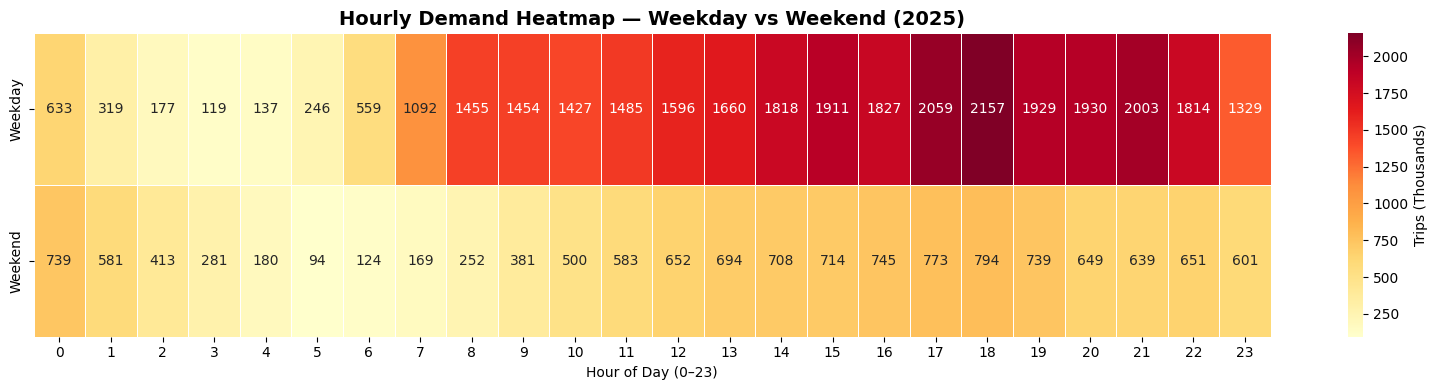

Task 2 done


In [7]:
# Hourly demand heatmap
hourly = (
    df.groupBy("pickup_hour", "is_weekend")
    .agg(F.count("*").alias("trips"))
    .toPandas()
)

hourly["day_type"] = hourly["is_weekend"].apply(lambda x: "Weekend" if x else "Weekday")

pivot = hourly.pivot_table(index="day_type", columns="pickup_hour", values="trips")

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    pivot/1000,
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Trips (Thousands)"}
)
ax.set_title("Hourly Demand Heatmap — Weekday vs Weekend (2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("hourly_demand_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Task 2 done")

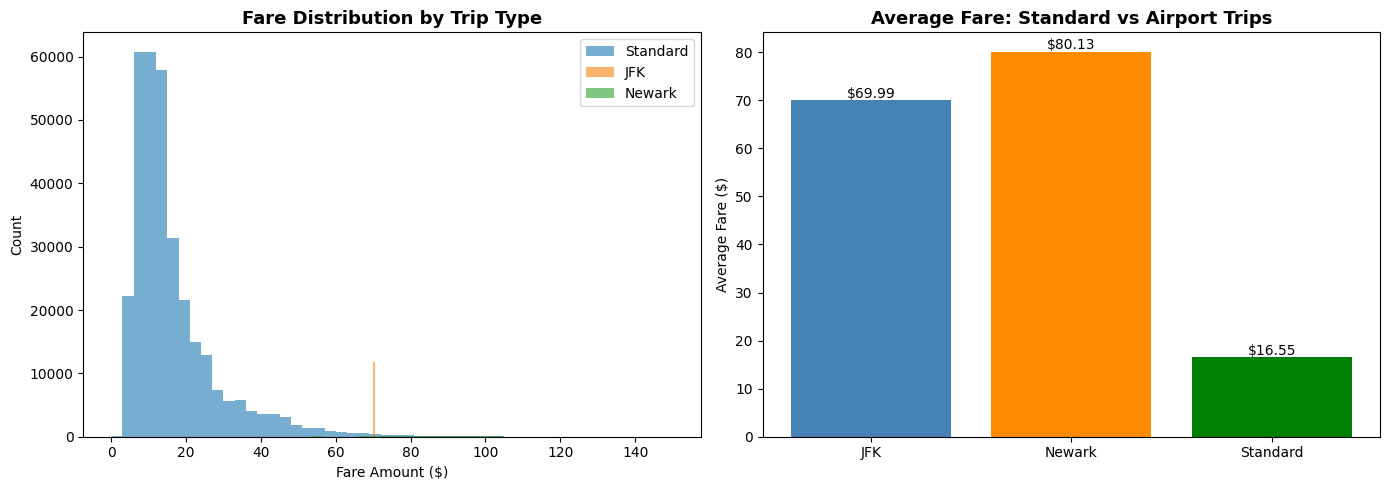


Trip Economics Summary:
ratecode_label    trips  avg_fare  avg_distance  avg_tip_pct  avg_fare_per_mile  avg_duration_min
           JFK  1188806     69.99         17.95        17.12               8.11             53.66
        Newark   121786     80.13         14.47        14.54              10.81             37.57
      Standard 32526616     16.55          2.64        22.41               8.48             15.11
Task 3 done


In [8]:
# Fare distribution & airport vs standard trip economics
fare_data = (
    df.filter(F.col("ratecode_label").isin(["Standard", "JFK", "Newark"]))
    .groupBy("ratecode_label")
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance"),
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("fare_per_mile"), 2).alias("avg_fare_per_mile"),
        F.round(F.avg("trip_duration_minutes"), 2).alias("avg_duration_min")
    )
    .toPandas()
)

# Fare distribution sample
fare_sample = (
    df.filter(
        (F.col("ratecode_label").isin(["Standard", "JFK", "Newark"])) &
        (F.col("fare_amount") <= 150)
    )
    .select("fare_amount", "ratecode_label")
    .sample(fraction=0.01)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare distribution by rate type
for label in ["Standard", "JFK", "Newark"]:
    subset = fare_sample[fare_sample["ratecode_label"] == label]
    axes[0].hist(subset["fare_amount"], bins=50, alpha=0.6, label=label)
axes[0].set_title("Fare Distribution by Trip Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Fare Amount ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Avg fare comparison
axes[1].bar(fare_data["ratecode_label"], fare_data["avg_fare"], color=["steelblue","darkorange","green"])
axes[1].set_title("Average Fare: Standard vs Airport Trips", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Average Fare ($)")
for i, v in enumerate(fare_data["avg_fare"]):
    axes[1].text(i, v + 0.5, f"${v}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fare_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTrip Economics Summary:")
print(fare_data.to_string(index=False))
print("Task 3 done")

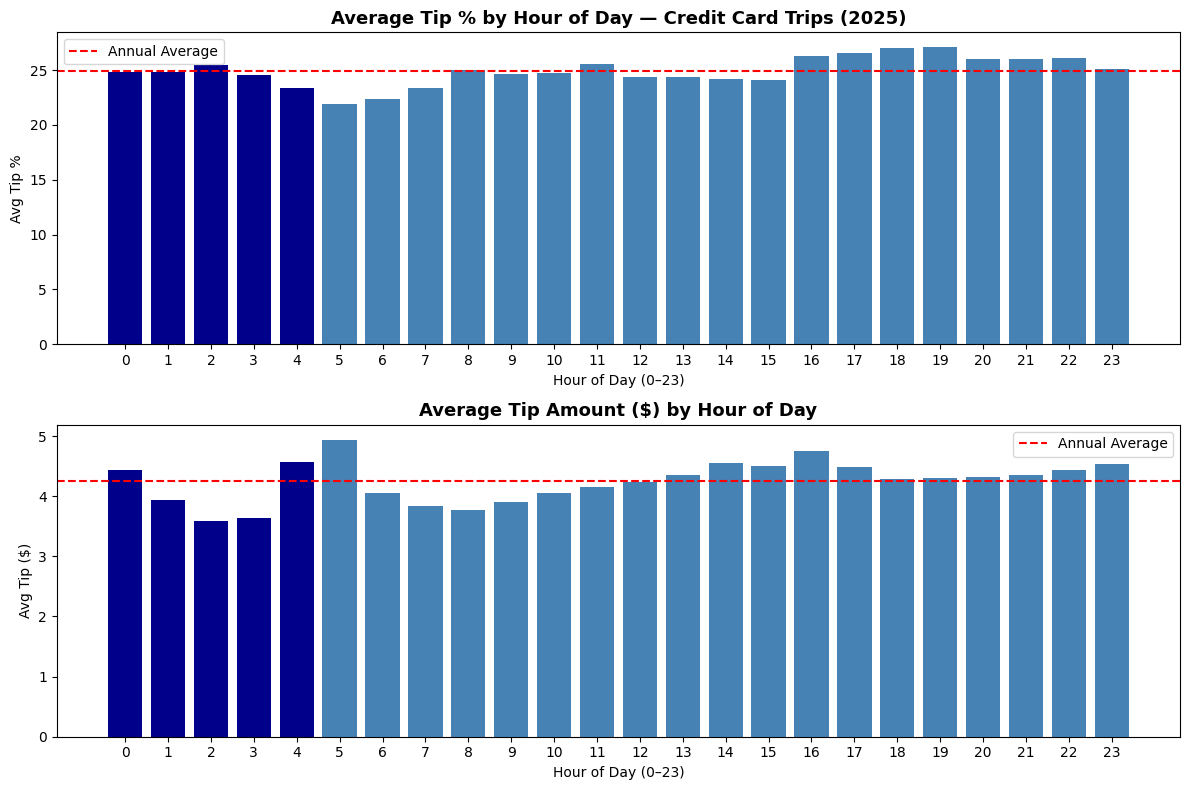


Late Night (12AM-4AM) vs Overall:
  Late night avg tip %  : 24.62%
  Overall avg tip %     : 24.91%
Task 4 done


In [9]:
# Tip rate analysis by hour
tip_hourly = (
    df.filter(F.col("payment_type") == 1)  # credit card only — cash tips not recorded
    .groupBy("pickup_hour")
    .agg(
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
        F.count("*").alias("trips")
    )
    .orderBy("pickup_hour")
    .toPandas()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Avg tip % by hour
colors = ["darkblue" if h in [0,1,2,3,4] else "steelblue" for h in tip_hourly["pickup_hour"]]
axes[0].bar(tip_hourly["pickup_hour"], tip_hourly["avg_tip_pct"], color=colors)
axes[0].set_title("Average Tip % by Hour of Day — Credit Card Trips (2025)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour of Day (0–23)")
axes[0].set_ylabel("Avg Tip %")
axes[0].axhline(y=tip_hourly["avg_tip_pct"].mean(), color="red", linestyle="--", label="Annual Average")
axes[0].legend()
axes[0].set_xticks(range(24))

# Avg tip amount by hour
axes[1].bar(tip_hourly["pickup_hour"], tip_hourly["avg_tip_amount"], color=colors)
axes[1].set_title("Average Tip Amount ($) by Hour of Day", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hour of Day (0–23)")
axes[1].set_ylabel("Avg Tip ($)")
axes[1].axhline(y=tip_hourly["avg_tip_amount"].mean(), color="red", linestyle="--", label="Annual Average")
axes[1].legend()
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig("tip_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLate Night (12AM-4AM) vs Overall:")
late_night = tip_hourly[tip_hourly["pickup_hour"].isin([0,1,2,3,4])]
print(f"  Late night avg tip %  : {late_night['avg_tip_pct'].mean():.2f}%")
print(f"  Overall avg tip %     : {tip_hourly['avg_tip_pct'].mean():.2f}%")
print("Task 4 done")

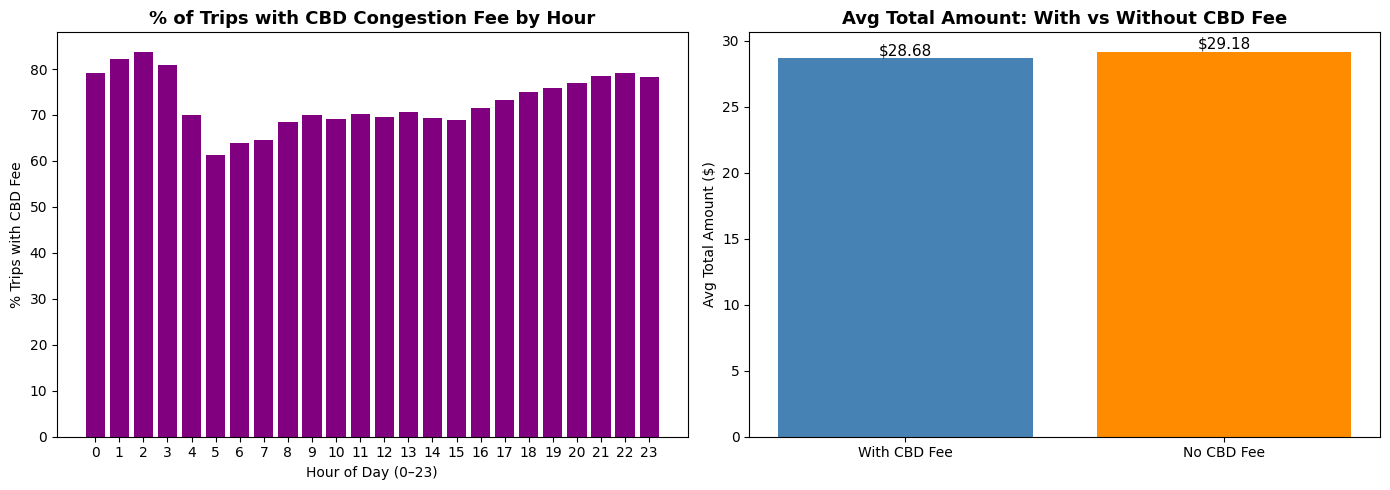


CBD Fee Behavioral Summary:
 has_cbd_fee    trips  avg_fare  avg_distance  avg_tip_pct  avg_total  avg_passengers  avg_duration
With CBD Fee 32020248     19.35          3.18        18.51      28.68            1.26         17.41
  No CBD Fee 11770183     21.73          4.38        15.81      29.18            1.20         18.39
Task 5 done


In [10]:
# CBD Congestion Fee impact
cbd = (
    df.withColumn("has_cbd_fee", F.when(F.col("cbd_congestion_fee") > 0, "With CBD Fee").otherwise("No CBD Fee"))
    .groupBy("has_cbd_fee")
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance"),
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("total_amount"), 2).alias("avg_total"),
        F.round(F.avg("passenger_count"), 2).alias("avg_passengers"),
        F.round(F.avg("trip_duration_minutes"), 2).alias("avg_duration")
    )
    .toPandas()
)

# CBD fee by hour
cbd_hourly = (
    df.withColumn("has_cbd_fee", F.when(F.col("cbd_congestion_fee") > 0, 1).otherwise(0))
    .groupBy("pickup_hour")
    .agg(
        F.round(F.avg("has_cbd_fee") * 100, 2).alias("pct_with_cbd_fee"),
        F.count("*").alias("trips")
    )
    .orderBy("pickup_hour")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CBD fee % by hour
axes[0].bar(cbd_hourly["pickup_hour"], cbd_hourly["pct_with_cbd_fee"], color="purple")
axes[0].set_title("% of Trips with CBD Congestion Fee by Hour", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour of Day (0–23)")
axes[0].set_ylabel("% Trips with CBD Fee")
axes[0].set_xticks(range(24))

# Avg total amount comparison
axes[1].bar(cbd["has_cbd_fee"], cbd["avg_total"], color=["steelblue", "darkorange"])
axes[1].set_title("Avg Total Amount: With vs Without CBD Fee", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Avg Total Amount ($)")
for i, v in enumerate(cbd["avg_total"]):
    axes[1].text(i, v + 0.2, f"${v}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("cbd_fee_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCBD Fee Behavioral Summary:")
print(cbd.to_string(index=False))
print("Task 5 done")

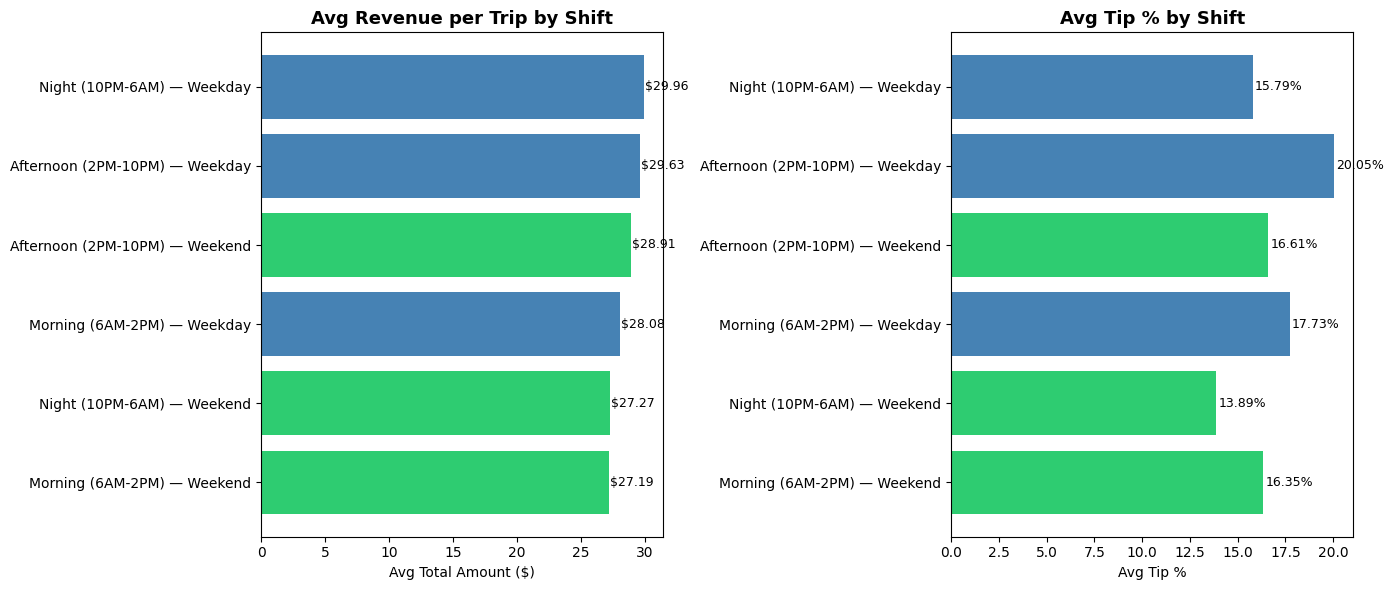


Best Shifts for Drivers:
                     shift_day  avg_total  avg_tip_pct  avg_duration
    Night (10PM-6AM) — Weekday      29.96        15.79         15.88
Afternoon (2PM-10PM) — Weekday      29.63        20.05         18.25
Afternoon (2PM-10PM) — Weekend      28.91        16.61         18.00
   Morning (6AM-2PM) — Weekday      28.08        17.73         18.90
    Night (10PM-6AM) — Weekend      27.27        13.89         15.14
   Morning (6AM-2PM) — Weekend      27.19        16.35         15.70
Task 6 done


In [11]:
# Driver revenue optimization — best shifts
shifts = (
    df.withColumn("shift",
        F.when(F.col("pickup_hour").between(6, 13), "Morning (6AM-2PM)")
         .when(F.col("pickup_hour").between(14, 21), "Afternoon (2PM-10PM)")
         .otherwise("Night (10PM-6AM)")
    )
    .groupBy("shift", "is_weekend")
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("total_amount"), 2).alias("avg_total"),
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("trip_duration_minutes"), 2).alias("avg_duration"),
        F.round(F.avg("trips_per_hour"), 2) if "trips_per_hour" in df.columns
            else F.round(F.avg("total_amount") / F.avg("trip_duration_minutes") * 60, 2).alias("revenue_per_hour")
    )
    .toPandas()
)

shifts["day_type"] = shifts["is_weekend"].apply(lambda x: "Weekend" if x else "Weekday")
shifts["shift_day"] = shifts["shift"] + " — " + shifts["day_type"]
shifts = shifts.sort_values("avg_total", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg total per trip by shift
colors = ["#2ecc71" if "Weekend" in s else "steelblue" for s in shifts["shift_day"]]
axes[0].barh(shifts["shift_day"], shifts["avg_total"], color=colors)
axes[0].set_title("Avg Revenue per Trip by Shift", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Avg Total Amount ($)")
for i, v in enumerate(shifts["avg_total"]):
    axes[0].text(v + 0.1, i, f"${v}", va="center", fontsize=9)

# Avg tip % by shift
axes[1].barh(shifts["shift_day"], shifts["avg_tip_pct"], color=colors)
axes[1].set_title("Avg Tip % by Shift", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Avg Tip %")
for i, v in enumerate(shifts["avg_tip_pct"]):
    axes[1].text(v + 0.1, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("driver_revenue_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBest Shifts for Drivers:")
print(shifts[["shift_day", "avg_total", "avg_tip_pct", "avg_duration"]].sort_values("avg_total", ascending=False).to_string(index=False))
print("Task 6 done")

In [12]:
print("=" * 50)
print("PHASE 2 — DEMAND & PRICING ANALYTICS COMPLETE")
print("=" * 50)
print("\nFiles saved:")
print("  ✓ monthly_seasonality.png")
print("  ✓ hourly_demand_heatmap.png")
print("  ✓ fare_distribution.png")
print("  ✓ tip_rate_analysis.png")
print("  ✓ cbd_fee_impact.png")
print("  ✓ driver_revenue_optimization.png")
print("\nTasks completed:")
print("  ✓ Task 1 — Monthly trip volume & revenue seasonality")
print("  ✓ Task 2 — Hourly demand heatmap (weekday vs weekend)")
print("  ✓ Task 3 — Fare distribution & airport vs standard economics")
print("  ✓ Task 4 — Tip rate analysis by hour (late night premium)")
print("  ✓ Task 5 — CBD Congestion Fee behavioral impact")
print("  ✓ Task 6 — Driver revenue optimization model")

spark.stop()
print("\n✓ Spark session closed")

PHASE 2 — DEMAND & PRICING ANALYTICS COMPLETE

Files saved:
  ✓ monthly_seasonality.png
  ✓ hourly_demand_heatmap.png
  ✓ fare_distribution.png
  ✓ tip_rate_analysis.png
  ✓ cbd_fee_impact.png
  ✓ driver_revenue_optimization.png

Tasks completed:
  ✓ Task 1 — Monthly trip volume & revenue seasonality
  ✓ Task 2 — Hourly demand heatmap (weekday vs weekend)
  ✓ Task 3 — Fare distribution & airport vs standard economics
  ✓ Task 4 — Tip rate analysis by hour (late night premium)
  ✓ Task 5 — CBD Congestion Fee behavioral impact
  ✓ Task 6 — Driver revenue optimization model

✓ Spark session closed
